### Data Extraction

In [1]:
import pandas as pd

#Change state
state = 'TX'

columns = ['placekey','city','naics_code','postal_code','date_range_start','date_range_end','visits_by_day']
df_state = pd.DataFrame(columns = columns)

for i in range(1,30):
    df = pd.read_csv('core_poi-geometry-patterns-part' + str(i) + '.csv')
    df = df[df['region'].isin([state])]
    df = df[columns]
    df.dropna(inplace=True)
    df_state = pd.concat([df_state,df])
    #print(i)

#Data output: change 'year_month.csv'
df_state.to_csv(state + '_2021_01.csv', index=False)

### Data Preprocessing

In [2]:
import pandas as pd

#Change state
state = 'TX'
#Change city
city = 'Texas'

#POI visit datasets
datasets = ['_2021_01','_2021_02','_2021_03','_2021_04']

for i in range(len(datasets)):
    df = pd.read_csv(state + datasets[i] + '.csv')
    #df = df[df['city'].isin([city])]
    df['category'] = df['naics_code'].apply(lambda x: str(x)[:2])
    df[['postal_code','category','visits_by_day']].to_csv(city + datasets[i] + '.csv', index=False)

### SDI-POI Dataset

In [3]:
import numpy as np
import pandas as pd

#Change city
city = 'Texas'

#Zip codes list from Census Bureau
df = pd.read_csv('SDI_Dataset.csv')
df['zip_code'] = df['NAME'].apply(lambda x: int(x[-5:]))
df['visits'] = -999
df['pre_disaster'] = -999
df['short_term'] = -999
df['long_term'] = -999
census_zip_codes = df['zip_code'].tolist()

#Data input
city_2021_01 = pd.read_csv(city + '_2021_01.csv')
city_2021_02 = pd.read_csv(city + '_2021_02.csv')
city_2021_03 = pd.read_csv(city + '_2021_03.csv')
city_2021_04 = pd.read_csv(city + '_2021_04.csv')

#Zip_codes list from SafeGraph
POI_zip_codes_a = set(city_2021_01['postal_code']) & set(city_2021_02['postal_code'])
POI_zip_codes_b = set(city_2021_03['postal_code']) & set(city_2021_04['postal_code'])
zip_codes = list(POI_zip_codes_a & POI_zip_codes_b & set(census_zip_codes))

#category = [[23],[31,32,33],[42],[44,45],[48,49],[52],[53],[56],[61],[62],[71],[72],[92]]
category = [23,31,32,33,42,44,45,48,49,52,53,56,61,62,71,72,92]

#Indicators calculation & Visualization
for code in zip_codes:
    df_2021_01 = city_2021_01[city_2021_01['postal_code'].isin([code])].reset_index()
    df_2021_02 = city_2021_02[city_2021_02['postal_code'].isin([code])].reset_index()
    df_2021_03 = city_2021_03[city_2021_03['postal_code'].isin([code])].reset_index()
    df_2021_04 = city_2021_04[city_2021_04['postal_code'].isin([code])].reset_index()
    df_2021_01 = df_2021_01[df_2021_01['category'].isin(category)].reset_index()
    df_2021_02 = df_2021_02[df_2021_02['category'].isin(category)].reset_index()
    df_2021_03 = df_2021_03[df_2021_03['category'].isin(category)].reset_index()
    df_2021_04 = df_2021_04[df_2021_04['category'].isin(category)].reset_index()
    
    visits_2021_01, visits_2021_02, visits_2021_03, visits_2021_04 = [0] * 31, [0] * 28, [0] * 31, [0] * 30
    for i in range(len(df_2021_01)):
        visits_2021_01 = np.sum([visits_2021_01, eval(df_2021_01['visits_by_day'][i])], axis=0)
    for i in range(len(df_2021_02)):
        visits_2021_02 = np.sum([visits_2021_02, eval(df_2021_02['visits_by_day'][i])], axis=0)
    for i in range(len(df_2021_03)):
        visits_2021_03 = np.sum([visits_2021_03, eval(df_2021_03['visits_by_day'][i])], axis=0)
    for i in range(len(df_2021_04)):
        visits_2021_04 = np.sum([visits_2021_04, eval(df_2021_04['visits_by_day'][i])], axis=0)
    
    visits_total = list(visits_2021_01) + list(visits_2021_02) + list(visits_2021_03) + list(visits_2021_04)
    df_visits = pd.DataFrame({'visits': visits_total}).rolling(7).mean()
    visits_01 = df_visits['visits'].tolist()[6:31]
    visits_02 = df_visits['visits'].tolist()[31:59]
    visits_03 = df_visits['visits'].tolist()[59:90]
    visits_04 = df_visits['visits'].tolist()[90:]
    
    #Baseline
    visits_sum = np.array(visits_01[2:9]) + np.array(visits_01[9:16]) + np.array(visits_01[16:23]) + np.array(visits_01[23:] + visits_02[:5])
    visits_mean = visits_sum / 4
    baseline = visits_mean.tolist() * 12
    if 0 in baseline:
        continue
    
    #Visits under a disaster
    visits = visits_02[5:] + visits_03 + visits_04
    
    #Percentage change
    percentage_change = []
    for i in range(len(visits)):
        percentage_change.append((visits[i] - baseline[i]) / baseline[i])
    percentage_change = percentage_change[:43]
    
    #Determination of during-disaster and post-disaster stages: pointer
    bottom = percentage_change.index(min(percentage_change))
    pointer = bottom
    while pointer < 42:
        pointer += 1
        if percentage_change[pointer] >= -0.1:
            break
    
    #Total visits
    df.loc[df[df['zip_code'] == code].index.tolist()[0],'visits'] = sum(visits_02[5:] + visits_03[:20])
    
    #Pre-disaster effect
    pre_sum = (max(percentage_change[0], 0) + max(percentage_change[7], 0)) / 2
    for i in range(1, 7):
        pre_sum += max(percentage_change[i], 0)
    df.loc[df[df['zip_code'] == code].index.tolist()[0],'pre_disaster'] = pre_sum
    
    #Short-term impact
    cur_sum = (percentage_change[7] + percentage_change[pointer]) / 2
    for i in range(8, pointer):
        cur_sum += percentage_change[i]
    df.loc[df[df['zip_code'] == code].index.tolist()[0],'short_term'] = cur_sum
    
    #Long-term impact
    df.loc[df[df['zip_code'] == code].index.tolist()[0],'long_term'] = np.mean(percentage_change[pointer:43])

#Data output
df.to_csv('SDI_POI_Dataset.csv',index=False)

### SDI-RI Dataset

In [4]:
import numpy as np
import pandas as pd

df = pd.read_csv('SDI_POI_Dataset.csv')

#Drop columns
df = df.drop(columns = ['Travel','zip_code','visits'])
#Drop rows
df = df.drop(df[df['short_term'] >= 0].index)
df = df.replace(-999, np.nan)
df = df.dropna()

#Convert numerical to categorical
df['pre_disaster'] = df['pre_disaster'].apply(lambda x: 1 if x > 0.35 else 0)
df['long_term'] = df['long_term'].apply(lambda x: 2 if x > 0.1 else (0 if x < -0.1 else 1))

#Convert numerical to percentile ranking
def percent_rank(pd_series):
    return list(np.round((pd_series < value).astype(int).sum()/(len(pd_series) -1), 4) for value in pd_series)

df['short_term'] = percent_rank(df['short_term'])

#Data output
df.to_csv('SDI_RI_Dataset.csv',index=False)

### POI Visits Visualization

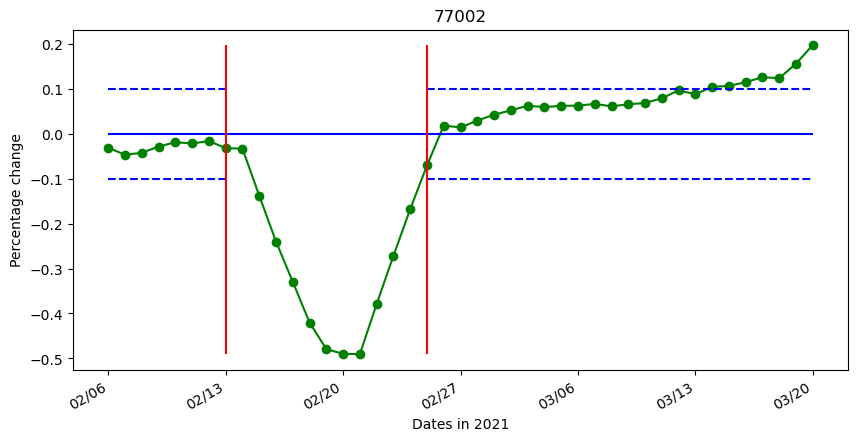

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

#Change city
city = 'Texas'

#Zip codes list from Census Bureau
df = pd.read_csv('SDI_Dataset.csv')
df['zip_code'] = df['NAME'].apply(lambda x: int(x[-5:]))
census_zip_codes = df['zip_code'].tolist()

#Data input
city_2021_01 = pd.read_csv(city + '_2021_01.csv')
city_2021_02 = pd.read_csv(city + '_2021_02.csv')
city_2021_03 = pd.read_csv(city + '_2021_03.csv')
city_2021_04 = pd.read_csv(city + '_2021_04.csv')

#Zip_codes list from SafeGraph
POI_zip_codes_a = set(city_2021_01['postal_code']) & set(city_2021_02['postal_code'])
POI_zip_codes_b = set(city_2021_03['postal_code']) & set(city_2021_04['postal_code'])
zip_codes = list(POI_zip_codes_a & POI_zip_codes_b & set(census_zip_codes))

#category = [[23],[31,32,33],[42],[44,45],[48,49],[52],[53],[56],[61],[62],[71],[72],[92]]
category = [23,31,32,33,42,44,45,48,49,52,53,56,61,62,71,72,92]
zip_codes = [77002]

#Indicators calculation & Visualization
for code in zip_codes:
    df_2021_01 = city_2021_01[city_2021_01['postal_code'].isin([code])].reset_index()
    df_2021_02 = city_2021_02[city_2021_02['postal_code'].isin([code])].reset_index()
    df_2021_03 = city_2021_03[city_2021_03['postal_code'].isin([code])].reset_index()
    df_2021_04 = city_2021_04[city_2021_04['postal_code'].isin([code])].reset_index()
    df_2021_01 = df_2021_01[df_2021_01['category'].isin(category)].reset_index()
    df_2021_02 = df_2021_02[df_2021_02['category'].isin(category)].reset_index()
    df_2021_03 = df_2021_03[df_2021_03['category'].isin(category)].reset_index()
    df_2021_04 = df_2021_04[df_2021_04['category'].isin(category)].reset_index()
    
    visits_2021_01, visits_2021_02, visits_2021_03, visits_2021_04 = [0] * 31, [0] * 28, [0] * 31, [0] * 30
    for i in range(len(df_2021_01)):
        visits_2021_01 = np.sum([visits_2021_01, eval(df_2021_01['visits_by_day'][i])], axis=0)
    for i in range(len(df_2021_02)):
        visits_2021_02 = np.sum([visits_2021_02, eval(df_2021_02['visits_by_day'][i])], axis=0)
    for i in range(len(df_2021_03)):
        visits_2021_03 = np.sum([visits_2021_03, eval(df_2021_03['visits_by_day'][i])], axis=0)
    for i in range(len(df_2021_04)):
        visits_2021_04 = np.sum([visits_2021_04, eval(df_2021_04['visits_by_day'][i])], axis=0)
    
    visits_total = list(visits_2021_01) + list(visits_2021_02) + list(visits_2021_03) + list(visits_2021_04)
    df_visits = pd.DataFrame({'visits': visits_total}).rolling(7).mean()
    visits_01 = df_visits['visits'].tolist()[6:31]
    visits_02 = df_visits['visits'].tolist()[31:59]
    visits_03 = df_visits['visits'].tolist()[59:90]
    visits_04 = df_visits['visits'].tolist()[90:]
    
    #Baseline
    visits_sum = np.array(visits_01[2:9]) + np.array(visits_01[9:16]) + np.array(visits_01[16:23]) + np.array(visits_01[23:] + visits_02[:5])
    visits_mean = visits_sum / 4
    baseline = visits_mean.tolist() * 12
    if 0 in baseline:
        continue
    
    #Visits under a disaster
    visits = visits_02[5:] + visits_03 + visits_04
    
    #Percentage change
    percentage_change = []
    for i in range(len(visits)):
        percentage_change.append((visits[i] - baseline[i]) / baseline[i])
    percentage_change = percentage_change[:43]
    
    #Determination of during-disaster and post-disaster stages: pointer
    bottom = percentage_change.index(min(percentage_change))
    pointer = bottom
    while pointer < 42:
        pointer += 1
        if percentage_change[pointer] >= -0.1:
            break
    
    #Visualization
    plt.figure(figsize = (10,5))
    dates = list(range(20210206,20210229)) + list(range(20210301,20210321))
    x = [datetime.strptime(str(d), '%Y%m%d').date() for d in dates]
    plt.plot(x, percentage_change, 'o-', color = 'g')
    plt.gcf().autofmt_xdate()
    
    plt.hlines(0, x[0], x[len(percentage_change)-1], color = 'b')
    plt.hlines(0.1, x[0], x[7], color = 'b', linestyle = 'dashed')
    plt.hlines(-0.1, x[0], x[7], color = 'b', linestyle = 'dashed')
    plt.hlines(0.1, x[pointer], x[len(percentage_change)-1], color = 'b', linestyle = 'dashed')
    plt.hlines(-0.1, x[pointer], x[len(percentage_change)-1], color = 'b', linestyle = 'dashed')
    plt.vlines(x[7], min(percentage_change), max(percentage_change), color = 'r')
    plt.vlines(x[pointer], min(percentage_change), max(percentage_change), color = 'r')
    
    plt.xlabel('Dates in 2021')
    plt.ylabel('Percentage change')
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
    plt.xticks(x[::7])
    
    plt.title(str(code))
    plt.show()